In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy
import pandas as pd
import pickle

import onep

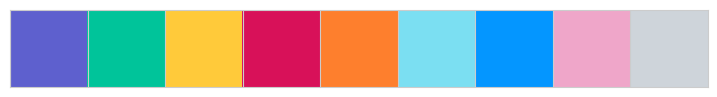

In [2]:
#Create color palette to match WaveMAP
CUSTOM_PAL_SORT_3 = ['#5e60ce','#00c49a','#ffca3a','#D81159','#fe7f2d','#7bdff2','#0496ff','#efa6c9','#ced4da']

sns.palplot(CUSTOM_PAL_SORT_3)

In [3]:
data = pd.read_csv('/Users/suthardr/Desktop/WaveMap_Plots/Recall_allmice/umap_recall_allmice_15.csv')
data

,Unnamed: 0,x,y,waveform,cluster_id,cluster_color,animal
0,0,8.212391,9.488578,[-1.49933398e-01 -9.81377086e-02 -5.75048816e-...,2,#ffca3a,astro3
1,1,6.486091,9.732696,[-0.26199635 -0.18109682 -0.1214645 -0.111929...,1,#00c49a,astro3
2,2,4.454976,10.010572,[-3.22850957e-01 -2.88176643e-01 -2.74698838e-...,1,#00c49a,astro3
3,3,3.272689,8.321077,[-0.18803624 -0.25228612 -0.33127771 -0.342589...,0,#5e60ce,astro3
4,4,6.770863,9.466758,[-0.52989485 -0.21231103 0.02031684 -0.137197...,1,#00c49a,astro3
...,...,...,...,...,...,...,...
1278,1278,8.919557,8.438970,[ 0.16261304 -0.3173657 -0.63884534 0.392181...,2,#ffca3a,astro9
1279,1279,8.245914,10.459826,[ 0.30996258 -0.00805848 -0.31215272 0.084400...,2,#ffca3a,astro9
1280,1280,7.220012,6.514396,[ 2.51428168e-01 1.77297357e-01 -4.99436566e-...,3,#D81159,astro9
1281,1281,6.283351,9.059857,[-6.50266582e-01 -2.88552065e-01 9.73602463e-...,1,#00c49a,astro9


In [4]:
#What percentage of each cluster is each animal?
clusters = np.unique(data['cluster_id'])
p_cluster_animal = []

#All animals
for cluster in clusters:
    df_cluster = data.loc[data['cluster_id']==cluster]
    percent_animal = [np.round(df_cluster.loc[df_cluster['animal']==ani].shape[0]/df_cluster.shape[0]*100,decimals=2) for ani in ['astro3','astro4','astro5','astro6','astro7','astro8','astro9']]
    p_cluster_animal.append(percent_animal)

#CxtA animals
# for cluster in clusters:
#     df_cluster = data.loc[data['cluster_id']==cluster]
#     percent_animal = [np.round(df_cluster.loc[df_cluster['animal']==ani].shape[0]/df_cluster.shape[0]*100,decimals=2) for ani in ['astro3','astro4','astro5','astro9']]
#     p_cluster_animal.append(percent_animal)

#CxtB animals
# for cluster in clusters:
#     df_cluster = data.loc[data['cluster_id']==cluster]
#     percent_animal = [np.round(df_cluster.loc[df_cluster['animal']==ani].shape[0]/df_cluster.shape[0]*100,decimals=2) for ani in ['astro6','astro7','astro8']]
#     p_cluster_animal.append(percent_animal)

In [ ]:
#CFC ALL MICE - donut plot with percentage in each cluster
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Initialize a list to store percentages for each cluster
p_cluster_animal = []
for cluster in clusters:
    # Filter data for the current cluster
    df_cluster = data[data['cluster_id'] == cluster]

    # Calculate percentages for each animal category
    total_count = df_cluster.shape[0]
    percent_animal = [np.round(df_cluster[df_cluster['animal'] == ani].shape[0] / total_count * 100, decimals=2) for ani in
    ['astro3', 'astro4', 'astro5', 'astro6', 'astro7', 'astro8', 'astro9']]

    # Append percentages to the list
    p_cluster_animal.append(percent_animal)


# Plot donut charts for each cluster in a 2-row grid
num_clusters = len(clusters)
num_cols = num_clusters // 2  # Number of columns per row (assuming 2 rows)

fig, axes = plt.subplots(nrows=2, ncols=num_cols, figsize=(15, 8))

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Iterate over clusters and percentages
for i, (cluster, percentages) in enumerate(zip(clusters, p_cluster_animal)):
    ax = axes[i]
    labels = ['astro3', 'astro4', 'astro5', 'astro6', 'astro7', 'astro8', 'astro9']
    colors = sns.color_palette('Set3')

    # Create a pie chart with centered percentages
    wedges, texts, autotexts = ax.pie(percentages, labels=labels, autopct='%1.1f%%', startangle=160, colors=colors, textprops={'fontsize': 12}, explode=[0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05], pctdistance=0.50)

    # Create a white circle in the center to turn the pie chart into a donut chart
    centre_circle = plt.Circle((0, 0), 0.40, color='white', edgecolor='black', linewidth=0.5)
    ax.add_artist(centre_circle)

    # Set title with increased fontsize
    ax.set_title(f'Cluster {cluster}', fontsize=16)

# Hide any unused subplots if there are an odd number of clusters
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()
fig.savefig('/Users/suthardr/Desktop/CFC_allmice_clusterbyanimal.svg')


/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_5805/2918399957.py:44: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  centre_circle = plt.Circle((0, 0), 0.40, color='white', edgecolor='black', linewidth=0.5)


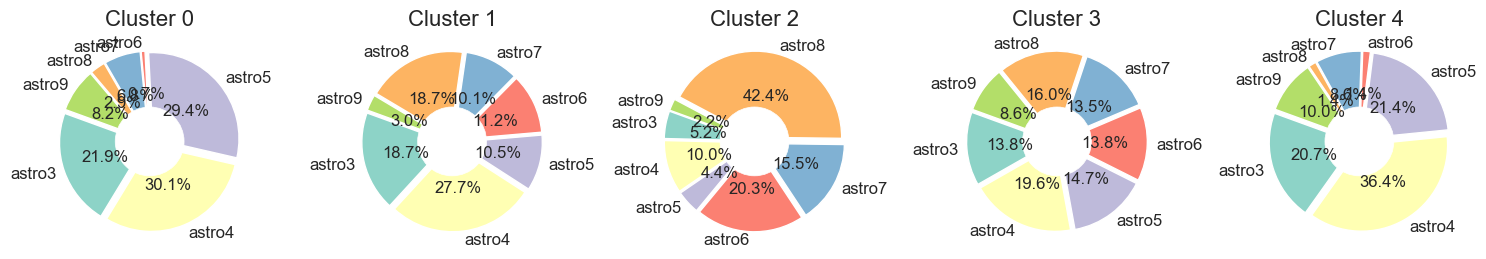

In [5]:
#RECALL ALL MICE - donut
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  # Assuming seaborn is imported for color palettes

# Assuming 'data' and 'clusters' are defined as per your code snippet

# Initialize a list to store percentages for each cluster
p_cluster_animal = []
for cluster in clusters:
    # Filter data for the current cluster
    df_cluster = data[data['cluster_id'] == cluster]

    # Calculate percentages for each animal category
    total_count = df_cluster.shape[0]
    percent_animal = [np.round(df_cluster[df_cluster['animal'] == ani].shape[0] / total_count * 100, decimals=2) for ani
                      in
                      ['astro3', 'astro4', 'astro5', 'astro6', 'astro7', 'astro8', 'astro9']]

    # Append percentages to the list
    p_cluster_animal.append(percent_animal)

# Plot donut charts for each cluster in a 2-row grid
num_clusters = len(clusters)
num_cols = num_clusters // 1  # Number of columns per row (assuming 2 rows)

fig, axes = plt.subplots(nrows=1, ncols=num_cols, figsize=(15, 8))

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Iterate over clusters and percentages
for i, (cluster, percentages) in enumerate(zip(clusters, p_cluster_animal)):
    ax = axes[i]
    labels = ['astro3', 'astro4', 'astro5', 'astro6', 'astro7', 'astro8', 'astro9']
    colors = sns.color_palette('Set3')

    # Create a pie chart with centered percentages
    wedges, texts, autotexts = ax.pie(percentages, labels=labels, autopct='%1.1f%%', startangle=160, colors=colors,
                                      textprops={'fontsize': 12}, explode=[0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05],
                                      pctdistance=0.50)

    # Create a white circle in the center to turn the pie chart into a donut chart
    centre_circle = plt.Circle((0, 0), 0.40, color='white', edgecolor='black', linewidth=0.5)
    ax.add_artist(centre_circle)

    # Set title with increased fontsize
    ax.set_title(f'Cluster {cluster}', fontsize=16)

# Hide any unused subplots if there are an odd number of clusters
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()
#fig.savefig('/Users/suthardr/Desktop/recall_allmice_clusterbyanimal.svg')


/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_5805/2233311752.py:38: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  centre_circle = plt.Circle((0, 0), 0.35, color='white', edgecolor='black', linewidth=0.5)


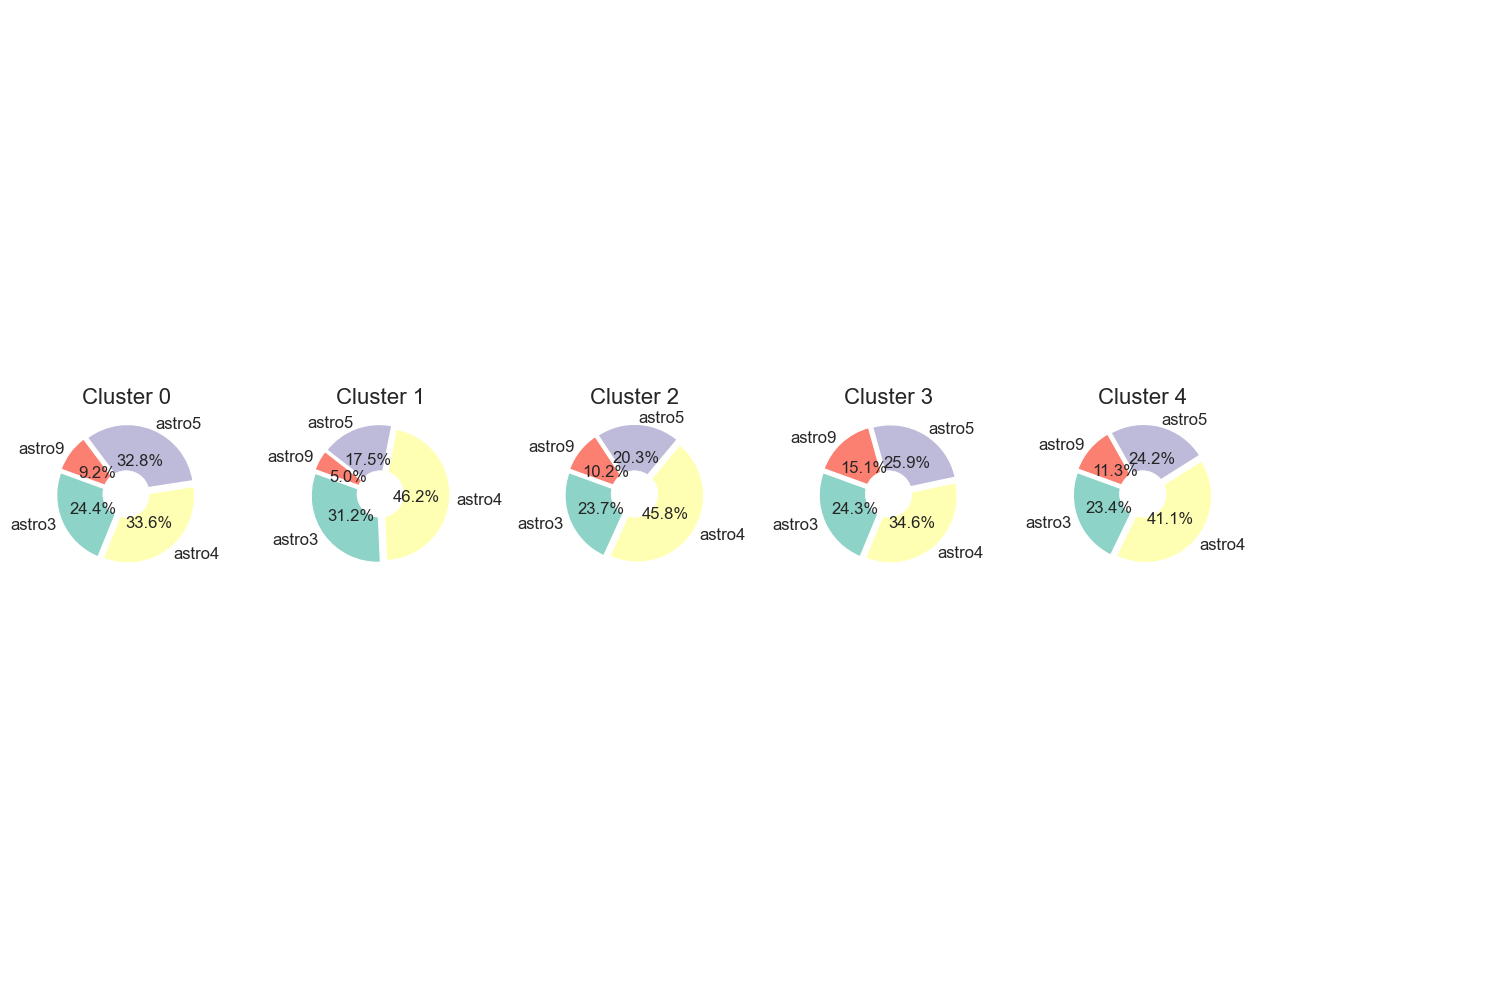

In [6]:
#Recall CXTA mice - donut percentage plot
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Initialize a list to store percentages for each cluster
p_cluster_animal = []
for cluster in clusters:
    # Filter data for the current cluster
    df_cluster = data[data['cluster_id'] == cluster]

    # Calculate percentages for each animal category
    total_count = df_cluster.shape[0]
    percent_animal = [np.round(df_cluster[df_cluster['animal'] == ani].shape[0] / total_count * 100, decimals=2) for ani in ['astro3', 'astro4', 'astro5', 'astro9']]

    # Append percentages to the list
    p_cluster_animal.append(percent_animal)

# Plot donut charts for each cluster in a 2-row grid
num_clusters = len(clusters)
num_cols = (num_clusters + 1) // 1  # Number of columns per row (adjust for odd numbers)

fig, axes = plt.subplots(nrows=1, ncols=num_cols, figsize=(15, 10))

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Iterate over clusters and percentages
for i, (cluster, percentages) in enumerate(zip(clusters, p_cluster_animal)):
    ax = axes[i]
    labels = ['astro3', 'astro4', 'astro5', 'astro9']
    colors = sns.color_palette('Set3')

    # Create a pie chart with centered percentages
    wedges, texts, autotexts = ax.pie(percentages, labels=labels, autopct='%1.1f%%', startangle=160, colors=colors, textprops={'fontsize': 12}, explode=[0.05, 0.05, 0.05, 0.05], pctdistance=0.50)
    #
    # Create a white circle in the center to turn the pie chart into a donut chart
    centre_circle = plt.Circle((0, 0), 0.35, color='white', edgecolor='black', linewidth=0.5)
    ax.add_artist(centre_circle)

    # Set title with increased fontsize
    ax.set_title(f'Cluster {cluster}', fontsize=16)

# Hide any unused subplots if there are an odd number of clusters
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()
#fig.savefig('/Users/suthardr/Desktop/recall_CXTA_clusterbyanimal.svg')

In [ ]:
#Recall CXTB mice - donut percentage plot
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Initialize a list to store percentages for each cluster
p_cluster_animal = []
for cluster in clusters:
    # Filter data for the current cluster
    df_cluster = data[data['cluster_id'] == cluster]

    # Calculate percentages for each animal category
    total_count = df_cluster.shape[0]
    percent_animal = [np.round(df_cluster[df_cluster['animal'] == ani].shape[0] / total_count * 100, decimals=2) for ani
                      in ['astro6', 'astro7', 'astro8']]

    # Append percentages to the list
    p_cluster_animal.append(percent_animal)

# Plot donut charts for each cluster in a 2-row grid
# num_clusters = len(clusters)
num_cols = (num_clusters + 1) // 1  # Number of columns per row (adjust for odd numbers)

fig, axes = plt.subplots(nrows=1, ncols=num_cols, figsize=(15, 8))

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Iterate over clusters and percentages
for i, (cluster, percentages) in enumerate(zip(clusters, p_cluster_animal)):
    ax = axes[i]
    labels = ['astro6', 'astro7', 'astro8']
    colors = sns.color_palette('Set3')

    # Create a pie chart with centered percentages
    wedges, texts, autotexts = ax.pie(percentages, labels=labels, autopct='%1.1f%%', startangle=160, colors=colors,
                                      textprops={'fontsize': 12}, explode=[0.05, 0.05, 0.05], pctdistance=0.50)
    #
    # Create a white circle in the center to turn the pie chart into a donut chart
    centre_circle = plt.Circle((0, 0), 0.35, color='white', edgecolor='black', linewidth=0.5)
    ax.add_artist(centre_circle)

    # Set title with increased fontsize
    ax.set_title(f'Cluster {cluster}', fontsize=16)

# Hide any unused subplots if there are an odd number of clusters
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()
#fig.savefig('/Users/suthardr/Desktop/recall_CXTB_clusterbyanimal.svg')

In [ ]:
#Plot ETA for Shock (120, 180, 240, 300) or Detected Sequences (Recall)
# Create a figure and axis object
fig, axs = plt.subplots()

n_clusters = 4
# Iterate through clusters 0 to 8 (adjust the range as needed)
for cluster_num in range(n_clusters):
    cluster_name = f'cluster{cluster_num}'

    onep.plot_whole_eta(data=globals()[cluster_name], ci='tci', sig_duration=10, axs=axs)

# Set labels and other plot settings (outside the loop)
axs.set_xticks(np.linspace(0, result.shape[1], 10),
labels=np.linspace(-7.5, 15, 10))
axs.axvline(x=75, color='black', linestyle='--')
axs.set_xlabel('Time (seconds)')
axs.set_ylabel(r'z-scored $\frac{dF}{F}$ (%)')
axs.grid(False)
sns.despine(ax=axs)

for cluster_num in range(n_clusters):
    cluster_name = f'cluster{cluster_num}'
    axs.get_lines()[cluster_num].set_color(CUSTOM_PAL_SORT_3[cluster_num])  # Set color for each line

# Show the plot
plt.show()
#fig.savefig('/Users/suthardr/Desktop/recall_CXTB_zscored_detected_ETA15sec.svg')